# Kang & Kim (2022) — nhân vector SDG và vẽ bảng

Notebook này **không load model**. Vector đã được `run_pipeline.py` lưu trong `data/embeddings/`.

Công thức paper: với mỗi câu báo cáo $r$ và mỗi mục tiêu $g$, điểm là **trung bình cosine** tới mọi câu SDG của mục tiêu đó. Cosine của hai vector đã L2-normalize chính là **tích vô hướng** $r^\top s$.

$$\mathrm{sim}(r, g) = \frac{1}{|S_g|} \sum_{s \in S_g} \hat r \cdot \hat s$$

Sau đó kéo min–max toàn cục về 0–100, gộp theo công ty–năm, rồi theo 6 nhóm SDG.

Chạy trước (một lần, có model):

```
python load_models.py --only vi_sbert vi_sentiment
python process_data.py
python run_pipeline.py --lang vi
```

## 0. Đường dẫn

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    ROOT = Path(r"C:\Code\paper_sdg")
sys.path.insert(0, str(ROOT))

from config import (
    CATEGORY_MAP,
    CATEGORY_ORDER,
    EMBED_DIR,
    FIGURE_DIR,
    GOAL_COLS,
    GOAL_TITLE_VI,
    RESULT_DIR,
)
from src.aggregate import category_means, company_year_means, minmax_scale_goals, sentiment_ratio
from src.encode import cosine_from_normalized, mean_similarity_by_goal

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT)
print("embeddings", list(EMBED_DIR.glob("*")))

C:\Users\admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT C:\Code\paper_sdg
embeddings [WindowsPath('C:/Code/paper_sdg/data/embeddings/.gitkeep'), WindowsPath('C:/Code/paper_sdg/data/embeddings/meta_vi.json'), WindowsPath('C:/Code/paper_sdg/data/embeddings/report_index_vi.pkl'), WindowsPath('C:/Code/paper_sdg/data/embeddings/report_vi.npy'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sdg_index_vi.pkl'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sdg_vi.npy'), WindowsPath('C:/Code/paper_sdg/data/embeddings/sim_vi.npy')]


## 1. Load vector đã lưu (không model)

Mỗi ngôn ngữ một cặp ma trận:
- `report_{lang}.npy` — `(n_câu_báo_cáo, dim)` đã L2-normalize
- `sdg_{lang}.npy` — `(n_câu_SDG, dim)` đã L2-normalize

Báo cáo hiện có chủ yếu tiếng Việt → ưu tiên `vi`. Tiếng Anh chạy khi có PDF EN.

In [2]:
def available_langs():
    out = []
    for lang in ("vi", "en"):
        if (EMBED_DIR / f"report_{lang}.npy").exists() and (EMBED_DIR / f"sdg_{lang}.npy").exists():
            out.append(lang)
    return out

LANGS = available_langs()
print("langs with embeddings:", LANGS)
if not LANGS:
    raise FileNotFoundError(
        "Chưa có file embedding. Chạy: python run_pipeline.py --lang vi --encode-only"
    )

langs with embeddings: ['vi']


## 2. Nhân vector = cosine similarity

`sim = report @ sdg.T` cho ma trận `(n_report, n_sdg)`.  
Cột được gộp theo `goalnum` bằng trung bình — đúng bước trong `02_sentence_similarity.ipynb` của paper.

In [3]:
parts = []
for lang in LANGS:
    report_emb = np.load(EMBED_DIR / f"report_{lang}.npy")
    sdg_emb = np.load(EMBED_DIR / f"sdg_{lang}.npy")
    report_idx = pd.read_pickle(EMBED_DIR / f"report_index_{lang}.pkl")
    sdg_idx = pd.read_pickle(EMBED_DIR / f"sdg_index_{lang}.pkl")

    print(f"[{lang}] report {report_emb.shape}  sdg {sdg_emb.shape}  (nhân cosine)")
    sim = cosine_from_normalized(report_emb, sdg_emb)
    print(f"[{lang}] sim {sim.shape}  min={sim.min():.3f}  max={sim.max():.3f}  mean={sim.mean():.3f}")

    goals = mean_similarity_by_goal(sim, sdg_idx["goalnum"], GOAL_COLS)
    part = pd.concat([report_idx.reset_index(drop=True), goals.reset_index(drop=True)], axis=1)
    parts.append(part)

    display(sdg_idx["goalnum"].value_counts().sort_index().to_frame("n_sdg_sentences").T)

df = pd.concat(parts, ignore_index=True)
print("rows", len(df), "files", df["fname"].nunique())
df.head(3)

[vi] report (95804, 768)  sdg (391, 768)  (nhân cosine)
[vi] sim (95804, 391)  min=-0.278  max=1.000  mean=0.202


goalnum,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
n_sdg_sentences,24,21,25,22,23,21,19,22,21,24,22,25,21,24,27,26,24


rows 95804 files 42


,doc_id,fname,company,year,doc_lang,sent_lang,sent_idx,sentence,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
0,0,BVH_SR_2020.pdf,BVH,2020,vi,vi,0,"Với Bảo Việt, chúng tôi đã chuẩn bị cho mình m...",0.306053,0.282368,0.282348,0.360152,0.269174,0.282502,0.348553,0.356579,0.399363,0.311556,0.307932,0.321420,0.330918,0.322249,0.361087,0.329500,0.413424
1,0,BVH_SR_2020.pdf,BVH,2020,vi,vi,1,"Có lẽ, sẽ cần cả một bộ phim để ghi lại những ...",0.183369,0.150384,0.154185,0.161020,0.145319,0.209133,0.176445,0.162421,0.190051,0.140420,0.183266,0.214086,0.203976,0.207246,0.183452,0.179094,0.174004
2,0,BVH_SR_2020.pdf,BVH,2020,vi,vi,2,Đại dịch COVID-19 xảy ra khiến cả thế giới cha...,0.270875,0.256325,0.197018,0.236703,0.204589,0.223647,0.277487,0.295688,0.296224,0.284664,0.269480,0.257062,0.324574,0.281937,0.298428,0.289330,0.359942


## 2b. Thống kê số câu và trung bình số câu trên trang mỗi báo cáo

Bảng tổng hợp cho 29 báo cáo: tổng số câu trích xuất, số trang PDF và mật độ câu/trang.

In [4]:
# Thống kê số câu và trung bình số câu trên trang cho từng báo cáo
import fitz
from config import PDF_DIR

pdf_map = {p.name: p for p in PDF_DIR.rglob('*.pdf')} if PDF_DIR.exists() else {}

stats = []
for (comp, yr, fn), grp in df.groupby(['company', 'year', 'fname'], sort=True):
    n_sents = len(grp)
    pdf_p = pdf_map.get(fn)
    n_pages = None
    if pdf_p and pdf_p.exists():
        try:
            doc = fitz.open(pdf_p)
            n_pages = len(doc)
            doc.close()
        except Exception:
            pass
    spp = round(n_sents / n_pages, 2) if n_pages else np.nan
    stats.append({
        'Công ty': comp,
        'Năm': yr,
        'Tên file': fn,
        'Số câu': n_sents,
        'Số trang': n_pages,
        'Số câu / trang': spp,
    })

df_doc_stats = pd.DataFrame(stats)

# Lưu bảng thống kê
out_stats_csv = RESULT_DIR / 'table_report_sentence_stats.csv'
df_doc_stats.to_csv(out_stats_csv, index=False, encoding='utf-8-sig')

tot_sents = df_doc_stats['Số câu'].sum()
avg_spp = df_doc_stats['Số câu / trang'].mean()
print(f'Tổng số báo cáo: {len(df_doc_stats)} | Tổng số câu: {tot_sents:,} | Trung bình: {avg_spp:.2f} câu/trang')
print(f'Đã lưu bảng thống kê vào: {out_stats_csv.name}')
display(df_doc_stats)


Tổng số báo cáo: 42 | Tổng số câu: 95,804 | Trung bình: 20.07 câu/trang
Đã lưu bảng thống kê vào: table_report_sentence_stats.csv


,Công ty,Năm,Tên file,Số câu,Số trang,Số câu / trang
0,BVH,2020,BVH_SR_2020.pdf,5627,410,13.72
1,BVH,2021,BVH_SR_2021.pdf,6388,222,28.77
2,BVH,2022,BVH_SR_2022.pdf,6419,386,16.63
3,BVH,2023,BVH_SR_2023.pdf,3691,279,13.23
4,BVH,2024,BVH_SR_2024.pdf,4037,314,12.86
5,BVH,2025,BVH_SR_2025.pdf,4515,346,13.05
6,PAN,2020,PAN_SR_2020.pdf,1464,83,17.64
7,PAN,2021,PAN_SR_2021.pdf,1572,76,20.68
8,PAN,2022,PAN_SR_2022.pdf,1630,67,24.33
9,PAN,2023,PAN_SR_2023.pdf,883,61,14.48


## 3. Kéo điểm similarity về 0–100

Paper: $(x - \min) \times 100 / (\max - \min)$ trên toàn bộ 17 cột goal.

In [5]:
df_s = minmax_scale_goals(df)
print("raw min", df_s.attrs.get("sim_min"), "raw max", df_s.attrs.get("sim_max"))
df_s[GOAL_COLS].describe().round(2)

raw min -0.07131676375865936 raw max 0.5308326482772827


,goal01,goal02,goal03,goal04,goal05,goal06,goal07,goal08,goal09,goal10,goal11,goal12,goal13,goal14,goal15,goal16,goal17
count,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00,95804.00
mean,46.27,45.11,42.95,44.09,38.09,42.43,48.21,47.45,48.76,44.81,44.20,48.46,44.24,44.64,46.32,45.64,50.65
std,12.08,11.93,10.06,12.34,11.01,11.41,11.06,12.66,12.91,9.96,10.62,11.63,10.42,10.24,11.91,10.72,14.06
min,3.30,0.00,6.77,6.36,3.82,2.09,7.01,7.67,1.27,5.45,7.75,8.53,3.50,5.89,5.57,5.42,6.36
25%,37.40,36.28,35.61,35.02,30.03,34.54,40.50,38.20,39.49,37.57,36.60,40.15,37.01,37.28,37.57,37.92,40.47
50%,46.12,44.93,42.88,43.29,37.87,42.01,48.07,47.23,48.25,44.98,43.90,48.44,43.93,44.65,46.26,45.73,49.81
75%,55.09,53.79,50.27,52.56,45.97,49.68,55.70,56.38,57.63,52.10,51.57,56.81,51.21,51.98,54.93,53.53,60.13
max,87.25,88.58,78.89,92.00,87.90,99.81,87.50,88.56,91.52,74.61,80.54,86.11,86.68,81.42,90.04,76.83,100.00


## 4. Bảng trung bình theo công ty × năm (17 SDG)

In [6]:
df_comp = company_year_means(df_s)
show = df_comp[GOAL_COLS].round(2)
show.columns = [f"{c}\n{GOAL_TITLE_VI[c]}" for c in GOAL_COLS]
display(show)
show.to_csv(RESULT_DIR / "table_company_year_17sdg.csv", encoding="utf-8-sig")
print("saved", RESULT_DIR / "table_company_year_17sdg.csv")

goal01\nChấm dứt nghèo  goal02\nKhông còn nạn đói  goal03\nSức khỏe và phúc lợi  goal04\nGiáo dục chất lượng  \
company year                                                                                                                 
BVH     2020               47.230000                  45.349998                     43.400002                    43.230000   
        2021               47.259998                  45.360001                     43.279999                    42.470001   
        2022               48.180000                  46.270000                     43.630001                    43.060001   
        2023               48.450001                  46.880001                     45.130001                    46.130001   
        2024               48.650002                  47.119999                     45.340000                    46.459999   
        2025               49.029999                  47.660000                     45.810001                    46.750000   
PAN     2020               44.970001                  45.740002                     41.290001                    43.279999   
        2021               46.380001                  47.220001                     42.349998                    43.930000   
        2022               46.660000                  47.410000                     42.660000                    44.369999   
        2023               44.400002                  45.459999                     41.040001                    43.290001   
        2024               45.259998                  47.090000                     41.779999                    44.459999   
        2025               46.320000                  47.470001                     43.099998                    45.330002   
PLX     2020               45.130001                  43.240002                     41.610001                    43.150002   
        2021               41.750000                  40.189999                     39.189999                    39.930000   
        2022               44.770000                  43.290001                     41.139999                    42.869999   
        2023               41.220001                  40.020000                     37.669998                    39.389999   
        2024               42.020000                  40.740002                     40.080002                    40.759998   
        2025               47.299999                  45.599998                     43.549999                    45.400002   
PNJ     2020               45.099998                  43.000000                     41.880001                    43.919998   
        2021               45.270000                  43.330002                     42.180000                    43.150002   
        2022               42.740002                  39.459999                     39.849998                    43.119999   
        2023               44.419998                  42.410000                     41.299999                    43.580002   
        2024               44.880001                  43.049999                     42.110001                    44.139999   
        2025               47.189999                  45.730000                     44.180000                    46.730000   
SSI     2020               44.430000                  42.610001                     40.660000                    42.759998   
        2021               46.070000                  43.930000                     41.759998                    43.860001   
        2022               46.709999                  44.790001                     42.150002                    44.650002   
        2023               45.869999                  43.970001                     41.509998                    44.240002   
        2024               47.669998                  46.070000                     43.330002                    46.419998   
        2025               42.770000                  38.860001                     40.119999               

saved C:\Code\paper_sdg\data\results\table_company_year_17sdg.csv


## 5. Gộp 17 SDG thành 6 nhóm (paper Table grouping)

| Nhóm | SDG |
|---|---|
| Life | 1, 2, 3 |
| Economic | 8, 9 |
| Equity | 4, 5, 10 |
| Social | 11, 16, 17 |
| Resources | 6, 7, 12, 14 |
| Environments | 13, 15 |

In [7]:
df_cat = category_means(df_comp)
display(df_cat.round(2))
df_cat.round(2).to_csv(RESULT_DIR / "table_company_year_6cat.csv", encoding="utf-8-sig")

category           Life   Economic     Equity     Social  Resources  Environments
company year                                                                     
BVH     2020  45.330002  47.930000  41.910000  47.299999  45.099998     44.639999
        2021  45.299999  47.959999  41.610001  47.049999  45.220001     44.930000
        2022  46.029999  48.380001  42.259998  47.570000  45.820000     45.490002
        2023  46.820000  50.169998  43.860001  48.470001  47.000000     46.580002
        2024  47.040001  50.680000  44.230000  49.000000  47.480000     47.250000
        2025  47.500000  51.040001  44.430000  49.410000  47.770000     47.590000
PAN     2020  44.000000  46.040001  40.790001  44.490002  44.119999     43.349998
        2021  45.320000  47.490002  42.150002  45.689999  44.860001     44.509998
        2022  45.570000  48.000000  42.759998  46.160000  45.770000     45.419998
        2023  43.630001  46.139999  41.230000  44.349998  43.480000     43.049999
        2024  44.709999  47.230000  41.770000  45.590000  45.599998     45.360001
        2025  45.630001  48.869999  42.770000  46.770000  46.599998     46.330002
PLX     2020  43.330002  46.470001  41.189999  45.340000  45.200001     44.360001
        2021  40.380001  43.830002  37.790001  42.689999  42.259998     41.470001
        2022  43.070000  46.119999  41.220001  44.619999  44.830002     44.040001
        2023  39.630001  41.759998  37.980000  41.709999  41.040001     40.889999
        2024  40.939999  46.389999  38.299999  44.990002  45.139999     45.139999
        2025  45.490002  48.709999  43.369999  47.139999  46.860001     46.410000
PNJ     2020  43.330002  47.630001  42.139999  46.389999  45.509998     44.450001
        2021  43.599998  47.470001  41.709999  45.730000  46.340000     45.029999
        2022  40.680000  45.380001  42.490002  45.669998  43.970001     43.509998
        2023  42.709999  46.419998  41.450001  45.520000  45.509998     44.020000
        2024  43.340000  47.349998  42.389999  46.270000  46.439999     44.950001
        2025  45.700001  49.880001  44.470001  48.310001  47.820000     47.040001
SSI     2020  42.560001  46.049999  41.270000  45.200001  43.130001     42.820000
        2021  43.919998  47.450001  42.169998  46.540001  44.110001     43.889999
        2022  44.549999  48.200001  43.000000  47.220001  44.860001     44.700001
        2023  43.779999  47.459999  42.570000  46.599998  44.080002     43.810001
        2024  45.689999  49.389999  44.580002  48.419998  46.070000     46.310001
        2025  40.590000  44.650002  38.360001  44.009998  42.330002     40.709999
VCS     2020  46.320000  50.709999  44.360001  48.959999  48.480000     47.180000
        2021  46.450001  50.980000  44.580002  49.349998  48.580002     47.270000
        2022  45.220001  49.980000  43.529999  48.230000  47.880001     46.209999
        2023  45.750000  50.139999  43.900002  48.549999  48.369999     46.810001
        2024  45.930000  50.520000  43.900002  48.889999  48.419998     47.020000
        2025  47.480000  51.900002  44.939999  50.509998  50.029999     49.349998
VNM     2020  40.410000  43.509998  38.660000  42.590000  42.360001     41.230000
        2021  40.830002  43.880001  38.840000  42.560001  42.259998     41.290001
        2022  40.290001  43.189999  38.580002  42.009998  42.529999     41.650002
        2023  43.110001  45.770000  41.189999  44.529999  44.869999     44.099998
        2024  43.340000  46.029999  41.299999  44.959999  45.099998     44.689999
        2025  45.599998  48.150002  43.099998  46.959999  47.330002     47.290001

## 6. Biểu đồ xu hướng 6 nhóm theo năm (từng công ty)

companies: ['BVH', 'PAN', 'PLX', 'PNJ', 'SSI', 'VCS', 'VNM']


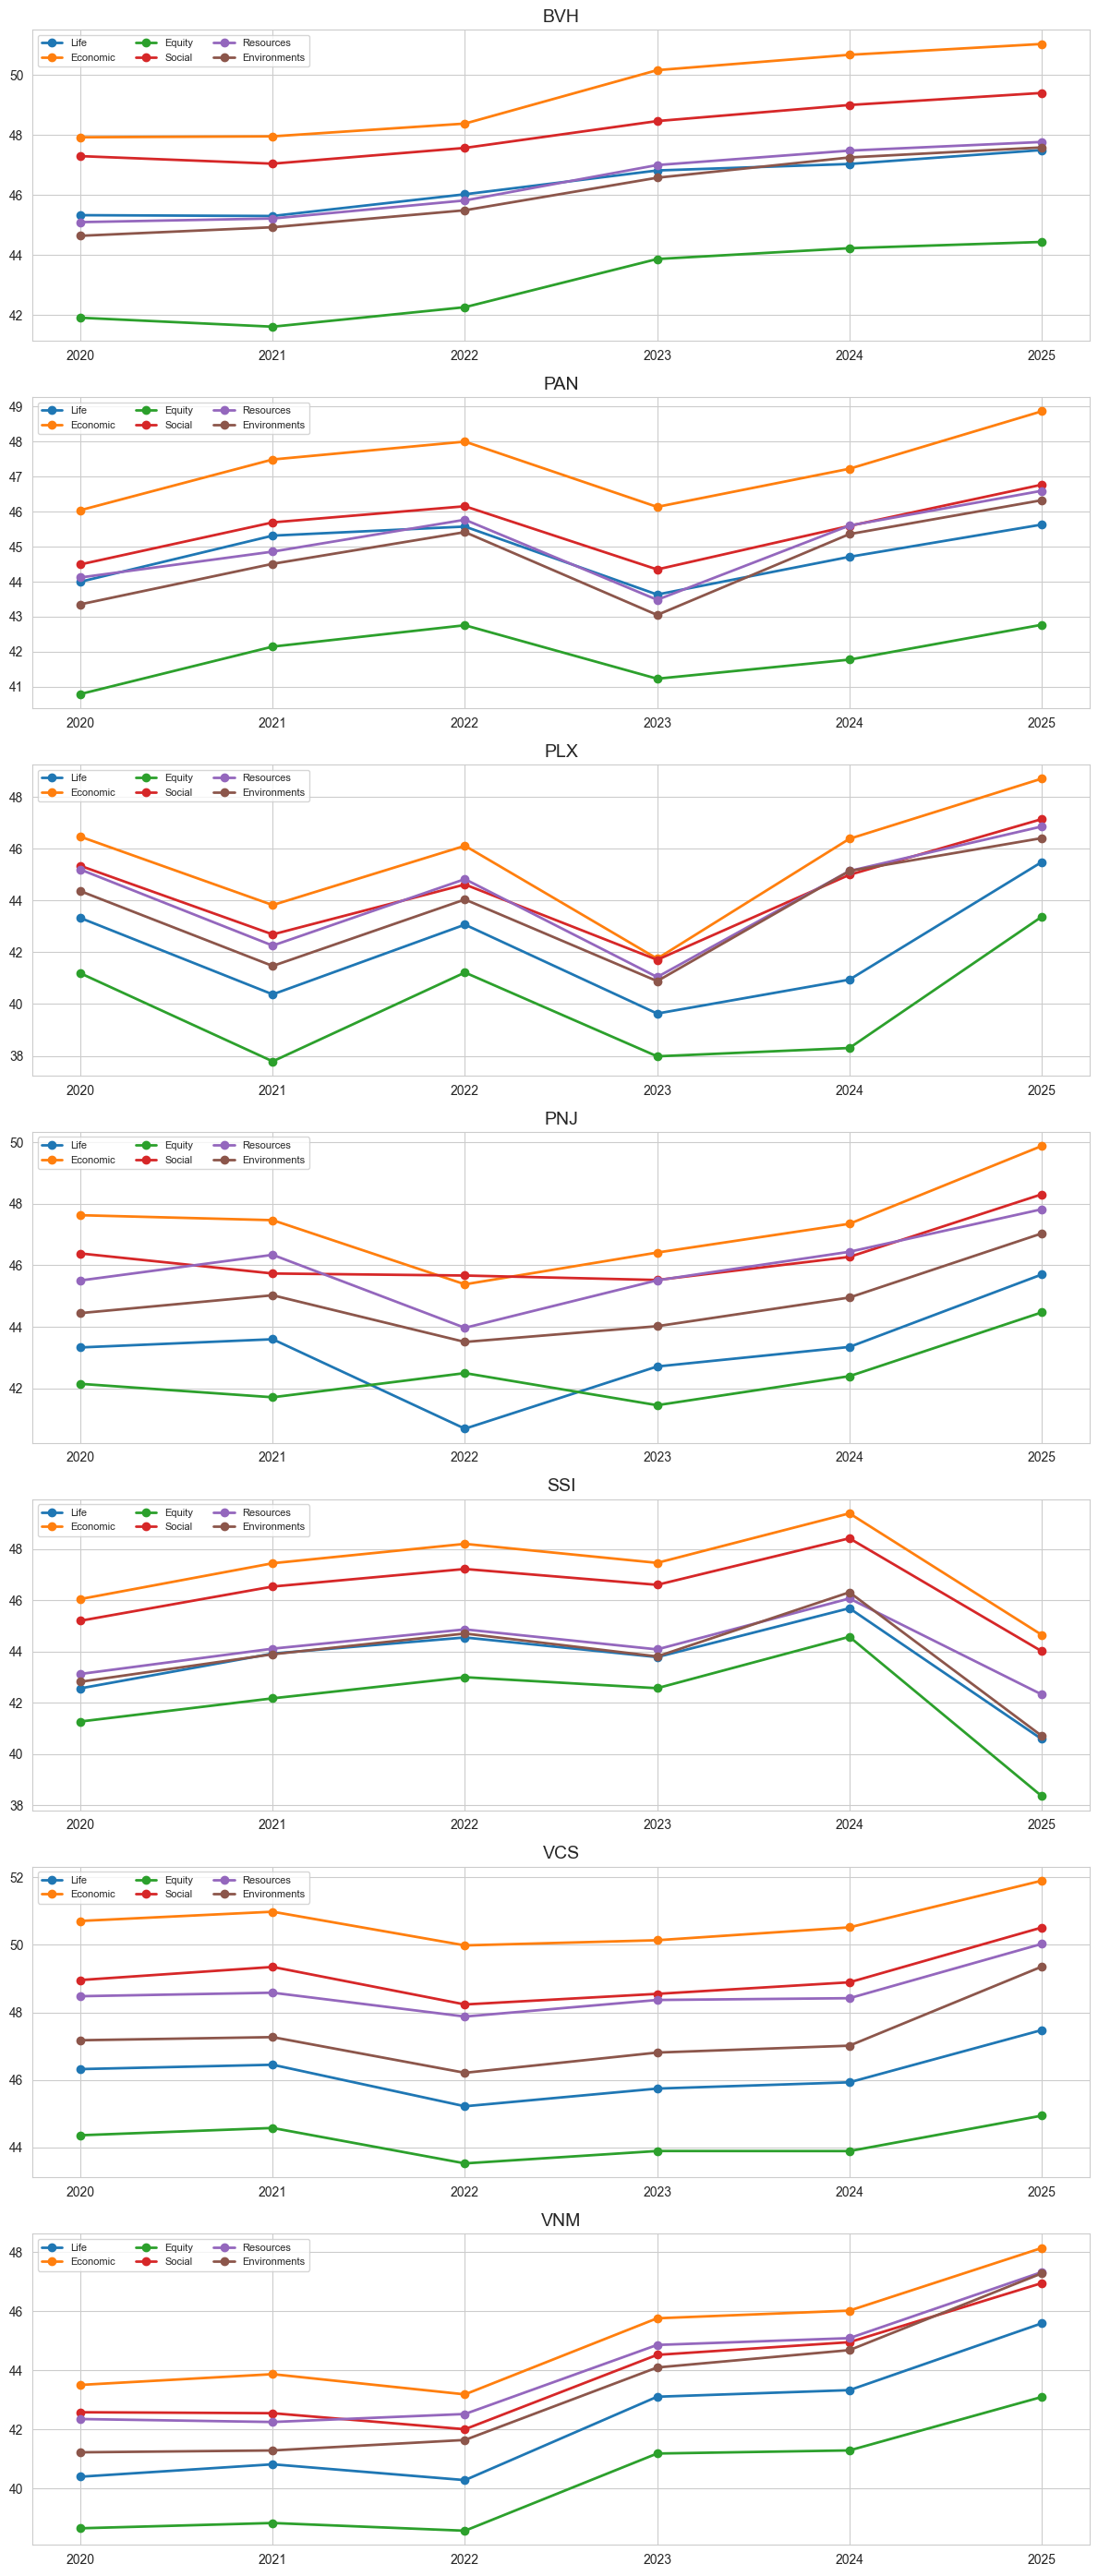

In [8]:
companies = sorted(df_s["company"].dropna().unique())
print("companies:", companies)

n = len(companies)
fig, axes = plt.subplots(n, 1, figsize=(12, 4 * max(n, 1)), squeeze=False)
for ax, company in zip(axes.ravel(), companies):
    sub = df_cat.loc[company].sort_index()
    for col in CATEGORY_ORDER:
        if col in sub.columns:
            ax.plot(sub.index.astype(str), sub[col], marker="o", linewidth=2, label=col)
    ax.set_title(company, fontsize=14)
    ax.grid(True)
    ax.legend(loc="best", fontsize=8, ncol=3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "trends_6categories.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Phân phối điểm similarity (sau scale 0–100)

mean 45.43 std 11.87


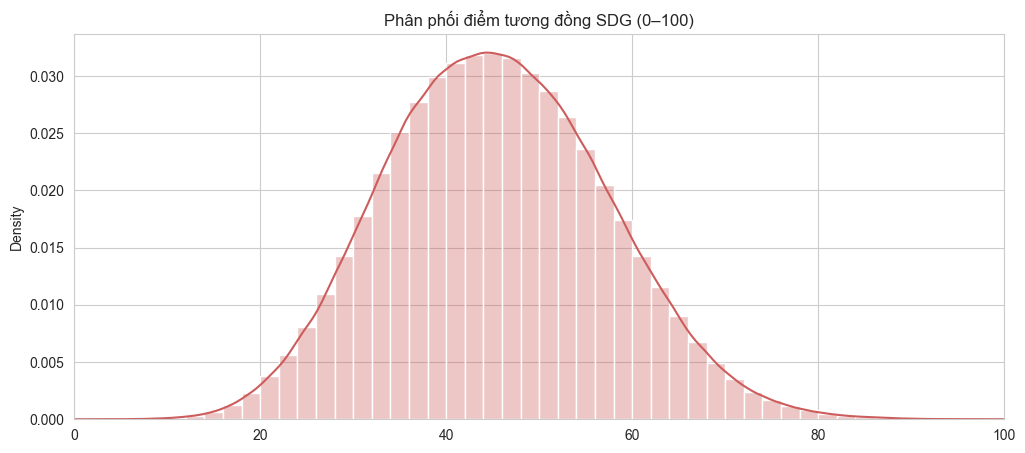

In [9]:
stacked = pd.concat([df_s[c] for c in GOAL_COLS], ignore_index=True)
print("mean", round(stacked.mean(), 2), "std", round(stacked.std(), 2))

fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(stacked, color="indianred", alpha=0.35, kde=True, stat="density", binwidth=2, ax=ax)
ax.set_xlim(0, 100)
ax.set_title("Phân phối điểm tương đồng SDG (0–100)")
fig.savefig(FIGURE_DIR / "similarity_hist.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Sentiment (nếu đã chạy `run_pipeline.py` đủ bước)

Paper: polarity 0–1 (NEGATIVE bị đảo `1 - score`). Tỷ lệ **Positive / Negative** theo năm.  
Tiếng Việt có thêm Neutral — không vào tử/mẫu của Ratio.

label
Positive    51652
Neutral     31615
Negative    12537
Name: count, dtype: int64


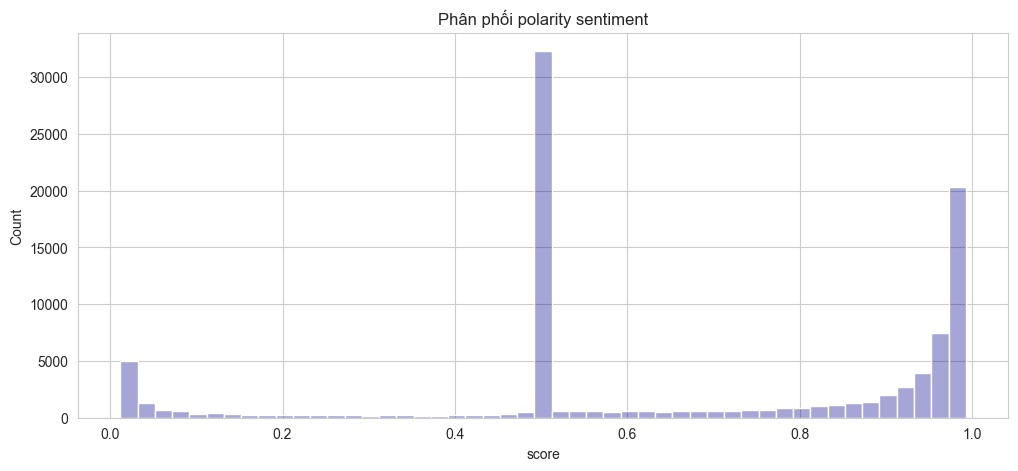

label         Negative  Neutral  Positive     Ratio
company year                                       
BVH     2020       663     2562      2402  3.622926
        2021       920     2941      2527  2.746739
        2022       853     2991      2575  3.018757
        2023       339     1245      2107  6.215339
        2024       403     1291      2343  5.813896
        2025       459     1361      2695  5.871460
PAN     2020       191      401       872  4.565445
        2021       220      352      1000  4.545455
        2022       237      401       992  4.185654
        2023       155      193       535  3.451613
        2024       187      414      1157  6.187166
        2025       269      578      1197  4.449814
PLX     2020       322      745       971  3.015528
        2021        35       63       108  3.085714
        2022       399      584       965  2.418546
        2023        95      165       709  7.463158
        2024        11       20        81  7.363636
        2025       182      405       790  4.340659
PNJ     2020       218      584      1037  4.756881
        2021       124      203       556  4.483871
        2022         9        0         3  0.333333
        2023       165      187       698  4.230303
        2024       257      315       917  3.568093
        2025       259      364       995  3.841699
SSI     2020       124      399       723  5.830645
        2021       138      280       795  5.760870
        2022       139      284       767  5.517986
        2023       125      311       767  6.136000
        2024       211      452      1006  4.767773
        2025       662      374       902  1.362538
VCS     2020       340      740      1094  3.217647
        2021       338      682      1119  3.310651
        2022       328      923      1204  3.670732
        2023       356      960      1138  3.196629
        2024       315      821      1380  4.380952
        2025       659     2320      2995  4.544765
VNM     2020       347      874      1810  5.216138
        2021       461     1044      2004  4.347072
        2022       339      947      1600  4.719764
        2023       213      538      1156  5.427230
        2024       234      570      1417  6.055556
        2025       236      731      1543  6.538136

company,BVH,PAN,PLX,PNJ,SSI,VCS,VNM
year,,,,,,,
2020,3.62,4.57,3.02,4.76,5.83,3.22,5.22
2021,2.75,4.55,3.09,4.48,5.76,3.31,4.35
2022,3.02,4.19,2.42,0.33,5.52,3.67,4.72
2023,6.22,3.45,7.46,4.23,6.14,3.20,5.43
2024,5.81,6.19,7.36,3.57,4.77,4.38,6.06
2025,5.87,4.45,4.34,3.84,1.36,4.54,6.54


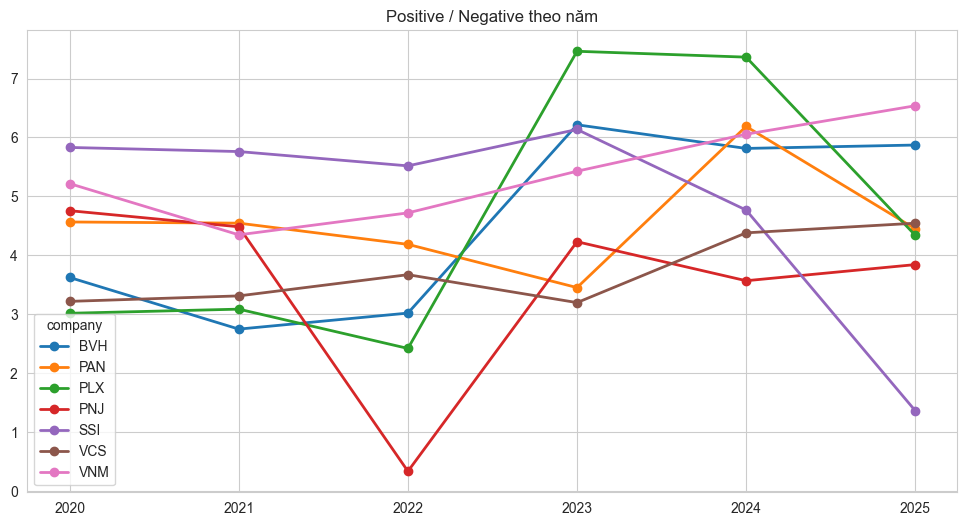

In [10]:
both_path = RESULT_DIR / "result_both.pkl"
if not both_path.exists():
    print("Chưa có sentiment. Chạy: python run_pipeline.py --lang vi")
else:
    df_both = pd.read_pickle(both_path)
    print(df_both["label"].value_counts(dropna=False))
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(df_both["score"].dropna(), color="darkblue", alpha=0.35, ax=ax)
    ax.set_title("Phân phối polarity sentiment")
    fig.savefig(FIGURE_DIR / "sentiment_hist.png", dpi=150, bbox_inches="tight")
    plt.show()

    counts = sentiment_ratio(df_both.dropna(subset=["label"]))
    display(counts)
    ratio = counts["Ratio"].unstack(level=0)
    display(ratio.round(2))
    fig, ax = plt.subplots(figsize=(12, 6))
    ratio.sort_index().plot(ax=ax, marker="o", linewidth=2)
    ax.set_title("Positive / Negative theo năm")
    ax.set_xlabel("")
    ax.grid(True)
    fig.savefig(FIGURE_DIR / "sentiment_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Heatmap công ty–năm × 6 nhóm

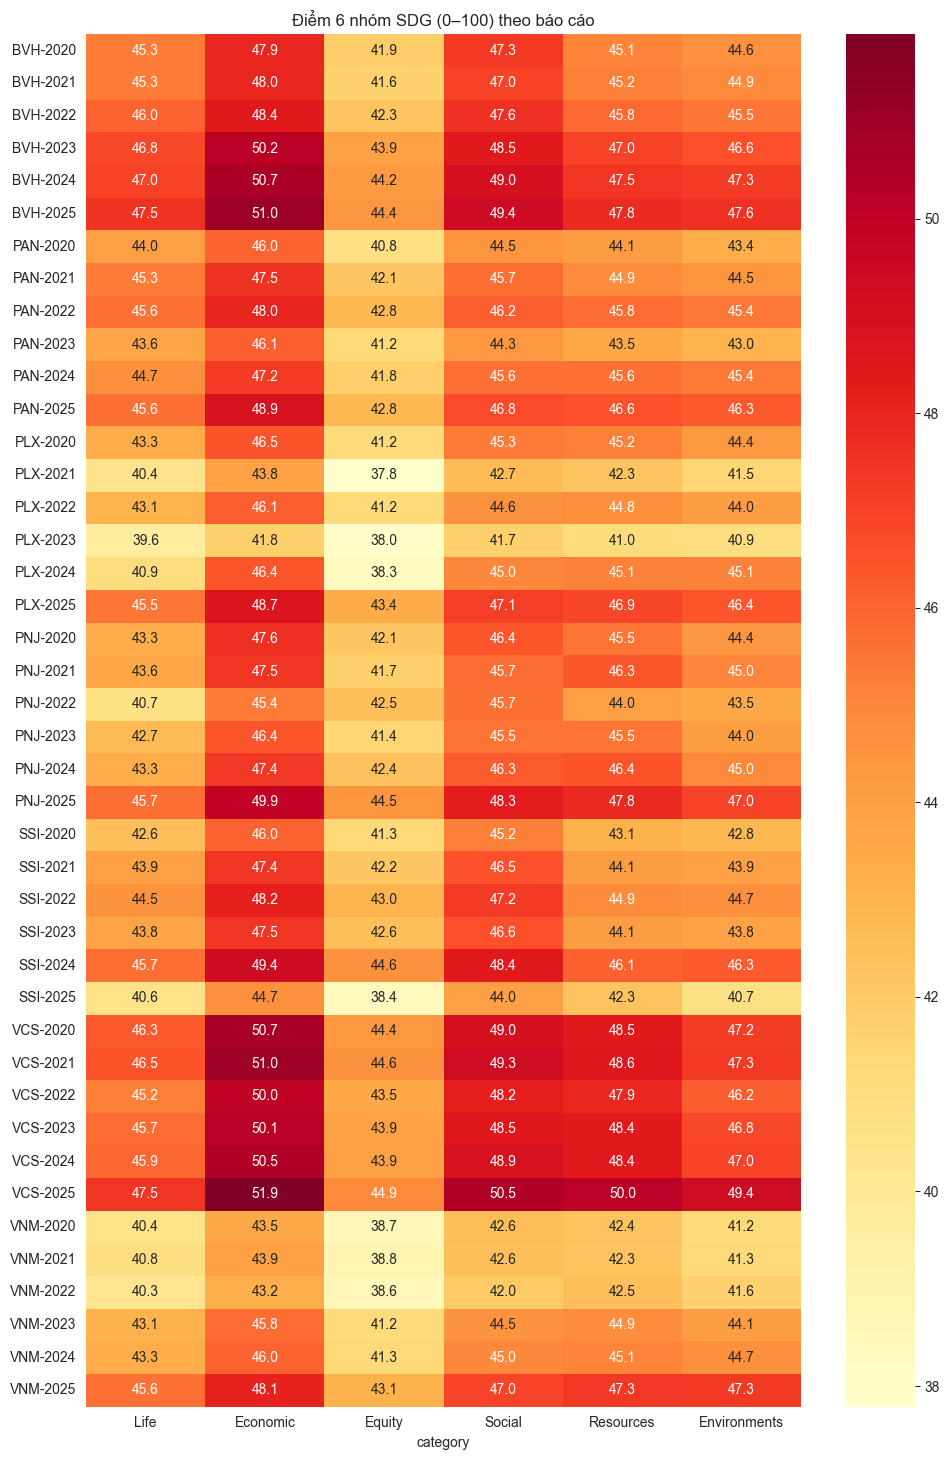

In [11]:
heat = df_cat.copy()
heat.index = [f"{c}-{y}" for c, y in heat.index]
fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(heat))))
sns.heatmap(heat[CATEGORY_ORDER], annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Điểm 6 nhóm SDG (0–100) theo báo cáo")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "heatmap_6cat.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Phân tích Sentiment riêng biệt từng công ty

Cơ cấu tỷ lệ các câu **Positive / Neutral / Negative** và đường tỷ lệ **Pos/Neg Ratio** của từng doanh nghiệp qua các năm.

Đã lưu biểu đồ: C:\Code\paper_sdg\figures\sentiment_by_company.png


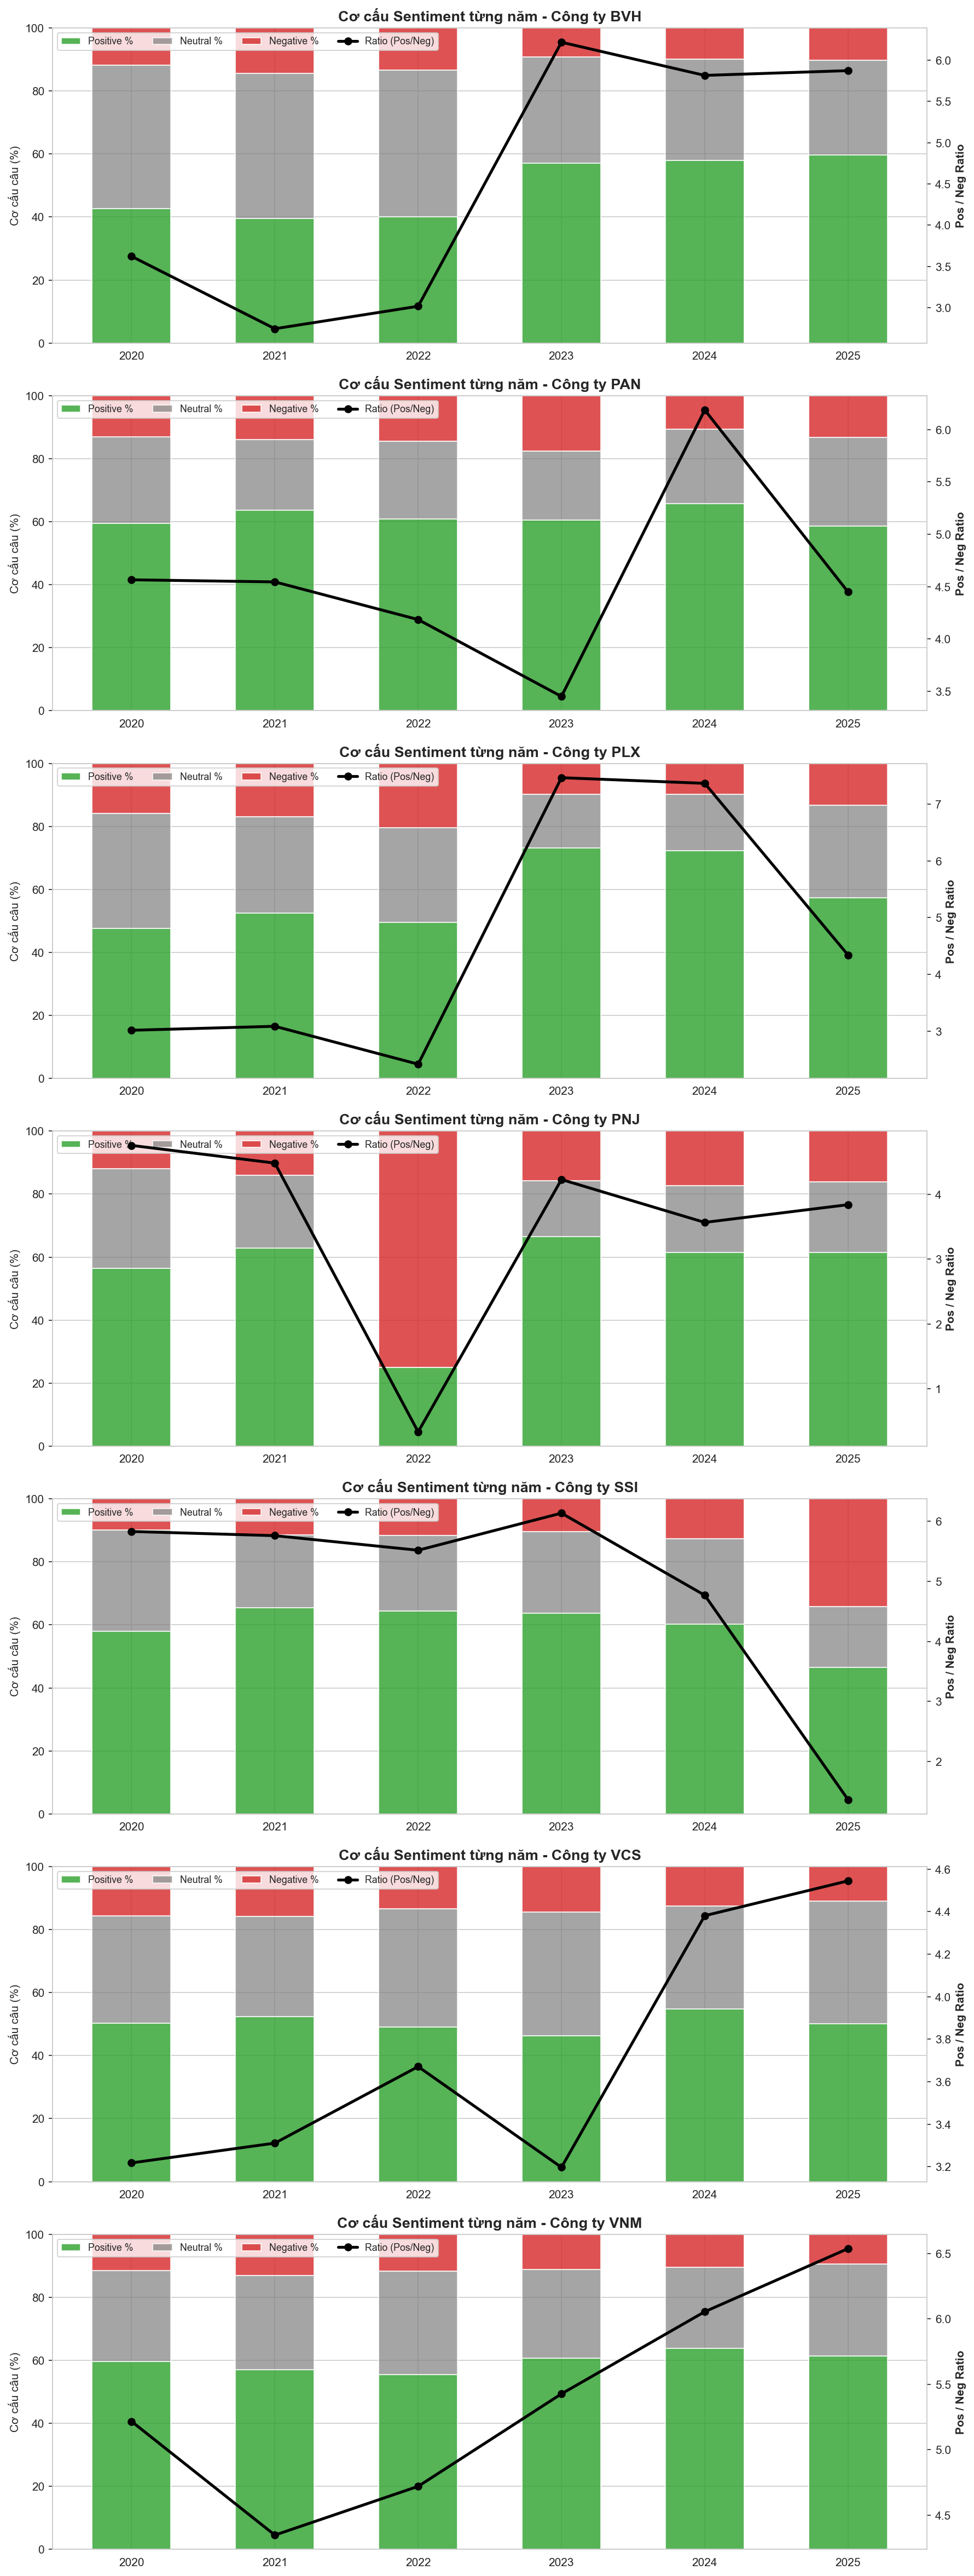

In [12]:
from src.plots import plot_sentiment_by_company

both_path = RESULT_DIR / 'result_both.pkl'
if both_path.exists():
    df_both = pd.read_pickle(both_path)
    counts = sentiment_ratio(df_both.dropna(subset=['label']))
    fig_senti_path = plot_sentiment_by_company(counts)
    print(f'Đã lưu biểu đồ: {fig_senti_path}')
    
    # Hiển thị ảnh trong notebook
    from IPython.display import Image
    display(Image(filename=str(fig_senti_path)))
else:
    print('Chưa có kết quả sentiment. Chạy pipeline sentiment để xem biểu đồ này.')


## 11. Giá cổ phiếu **theo tháng** vs Pos/Neg — có liên quan không?

Báo cáo PTBV ra **một lần/năm** nên Pos/Neg là 1 số/năm, vẽ **ziczac đỉnh giữa năm** (tô nền như ngọn núi). Giá cổ phiếu vẫn là đường **từng tháng**.

Cả hai kéo về **index 100 = tháng đầu** (cùng một trục) để nhìn được chúng đi cùng chiều hay ngược chiều. Không vẽ điểm SDG môi trường — cờ chỉ so **giá** với **giọng văn**.

Khi **giá cả năm tụt > 10%**:

| Phản ứng | Điều kiện | Ý nghĩa |
|---|---|---|
| **Tẩy xanh** | Pos/Neg tăng > 15% | Giọng văn hồng hơn khi thị trường phạt |
| **Trung thực** | Pos/Neg giảm | Giọng văn cũng kém đi cùng giá |
| **None** | Giá không tụt đủ, hoặc Pos/Neg không đổi rõ | Không kết luận |

Bảng correlation: Pearson/Spearman giữa **% đổi giá năm** và **% đổi Pos/Neg**. `n` chỉ ~6 năm/công ty — `p ≥ 0.10` thì ghi **None**, không suy từ mẫu nhỏ.


[stock] using monthly cache
Bảng tăng/giảm giá cổ phiếu và sentiment ratio (Pos/Neg) theo năm


,company,year,gia_cuoi_nam,gia_tang_giam_%,Positive,Negative,sent_ratio,sent_ratio_tang_giam_%,phan_ung
0,BVH,2019,58525.0,NaN,NaN,NaN,NaN,NaN,None
1,BVH,2020,57129.0,-2.39,2402.0,663.0,3.62,NaN,None
2,BVH,2021,49161.0,-13.95,2527.0,920.0,2.75,-24.18,Trung thực
3,BVH,2022,43618.0,-11.28,2575.0,853.0,3.02,9.90,None
4,BVH,2023,37870.0,-13.18,2107.0,339.0,6.22,105.89,Tẩy xanh
5,BVH,2024,49747.0,31.36,2343.0,403.0,5.81,-6.46,None
6,BVH,2025,56800.0,14.18,2695.0,459.0,5.87,0.99,None
7,PAN,2019,16034.0,NaN,NaN,NaN,NaN,NaN,None
8,PAN,2020,24839.0,54.91,872.0,191.0,4.57,NaN,None
9,PAN,2021,28136.0,13.27,1000.0,220.0,4.55,-0.44,None


Giá tăng/giảm YoY (%)


year,2019,2020,2021,2022,2023,2024,2025
company,,,,,,,
BVH,NaN,-2.39,-13.95,-11.28,-13.18,31.36,14.18
PAN,NaN,54.91,13.27,-61.17,35.12,20.06,16.65
PLX,NaN,4.67,0.79,-38.69,10.75,12.95,-2.71
PNJ,NaN,-3.03,20.67,26.90,-1.86,16.16,1.33
SSI,NaN,126.28,132.83,-62.17,92.61,1.73,30.73
VCS,NaN,31.00,39.07,-47.46,4.77,22.04,-26.98
VNM,NaN,15.34,-17.46,-5.76,-7.53,-0.92,4.77


Sentiment ratio Pos/Neg theo năm


year,2019,2020,2021,2022,2023,2024,2025
company,,,,,,,
BVH,NaN,3.62,2.75,3.02,6.22,5.81,5.87
PAN,NaN,4.57,4.55,4.19,3.45,6.19,4.45
PLX,NaN,3.02,3.09,2.42,7.46,7.36,4.34
PNJ,NaN,4.76,4.48,0.33,4.23,3.57,3.84
SSI,NaN,5.83,5.76,5.52,6.14,4.77,1.36
VCS,NaN,3.22,3.31,3.67,3.20,4.38,4.54
VNM,NaN,5.22,4.35,4.72,5.43,6.06,6.54


Correlation: r giữa % đổi giá năm và % đổi Pos/Neg


,company,n,r_pearson,p_pearson,r_spearman,p_spearman,doc
0,BVH,5,-0.355,0.558,0.000,1.000,None
1,PAN,5,0.134,0.830,-0.100,0.873,None
2,PLX,5,0.434,0.465,0.600,0.285,None
3,PNJ,5,-0.692,0.195,-0.900,0.037,None
4,SSI,5,0.237,0.701,0.500,0.391,None
5,VCS,5,0.125,0.842,-0.200,0.747,None
6,VNM,5,0.717,0.173,0.100,0.873,None
7,Tổng (pool),35,-0.046,0.791,-0.098,0.575,None


Đã lưu C:\Code\paper_sdg\figures\stock_vs_sentiment_greenwashing.png


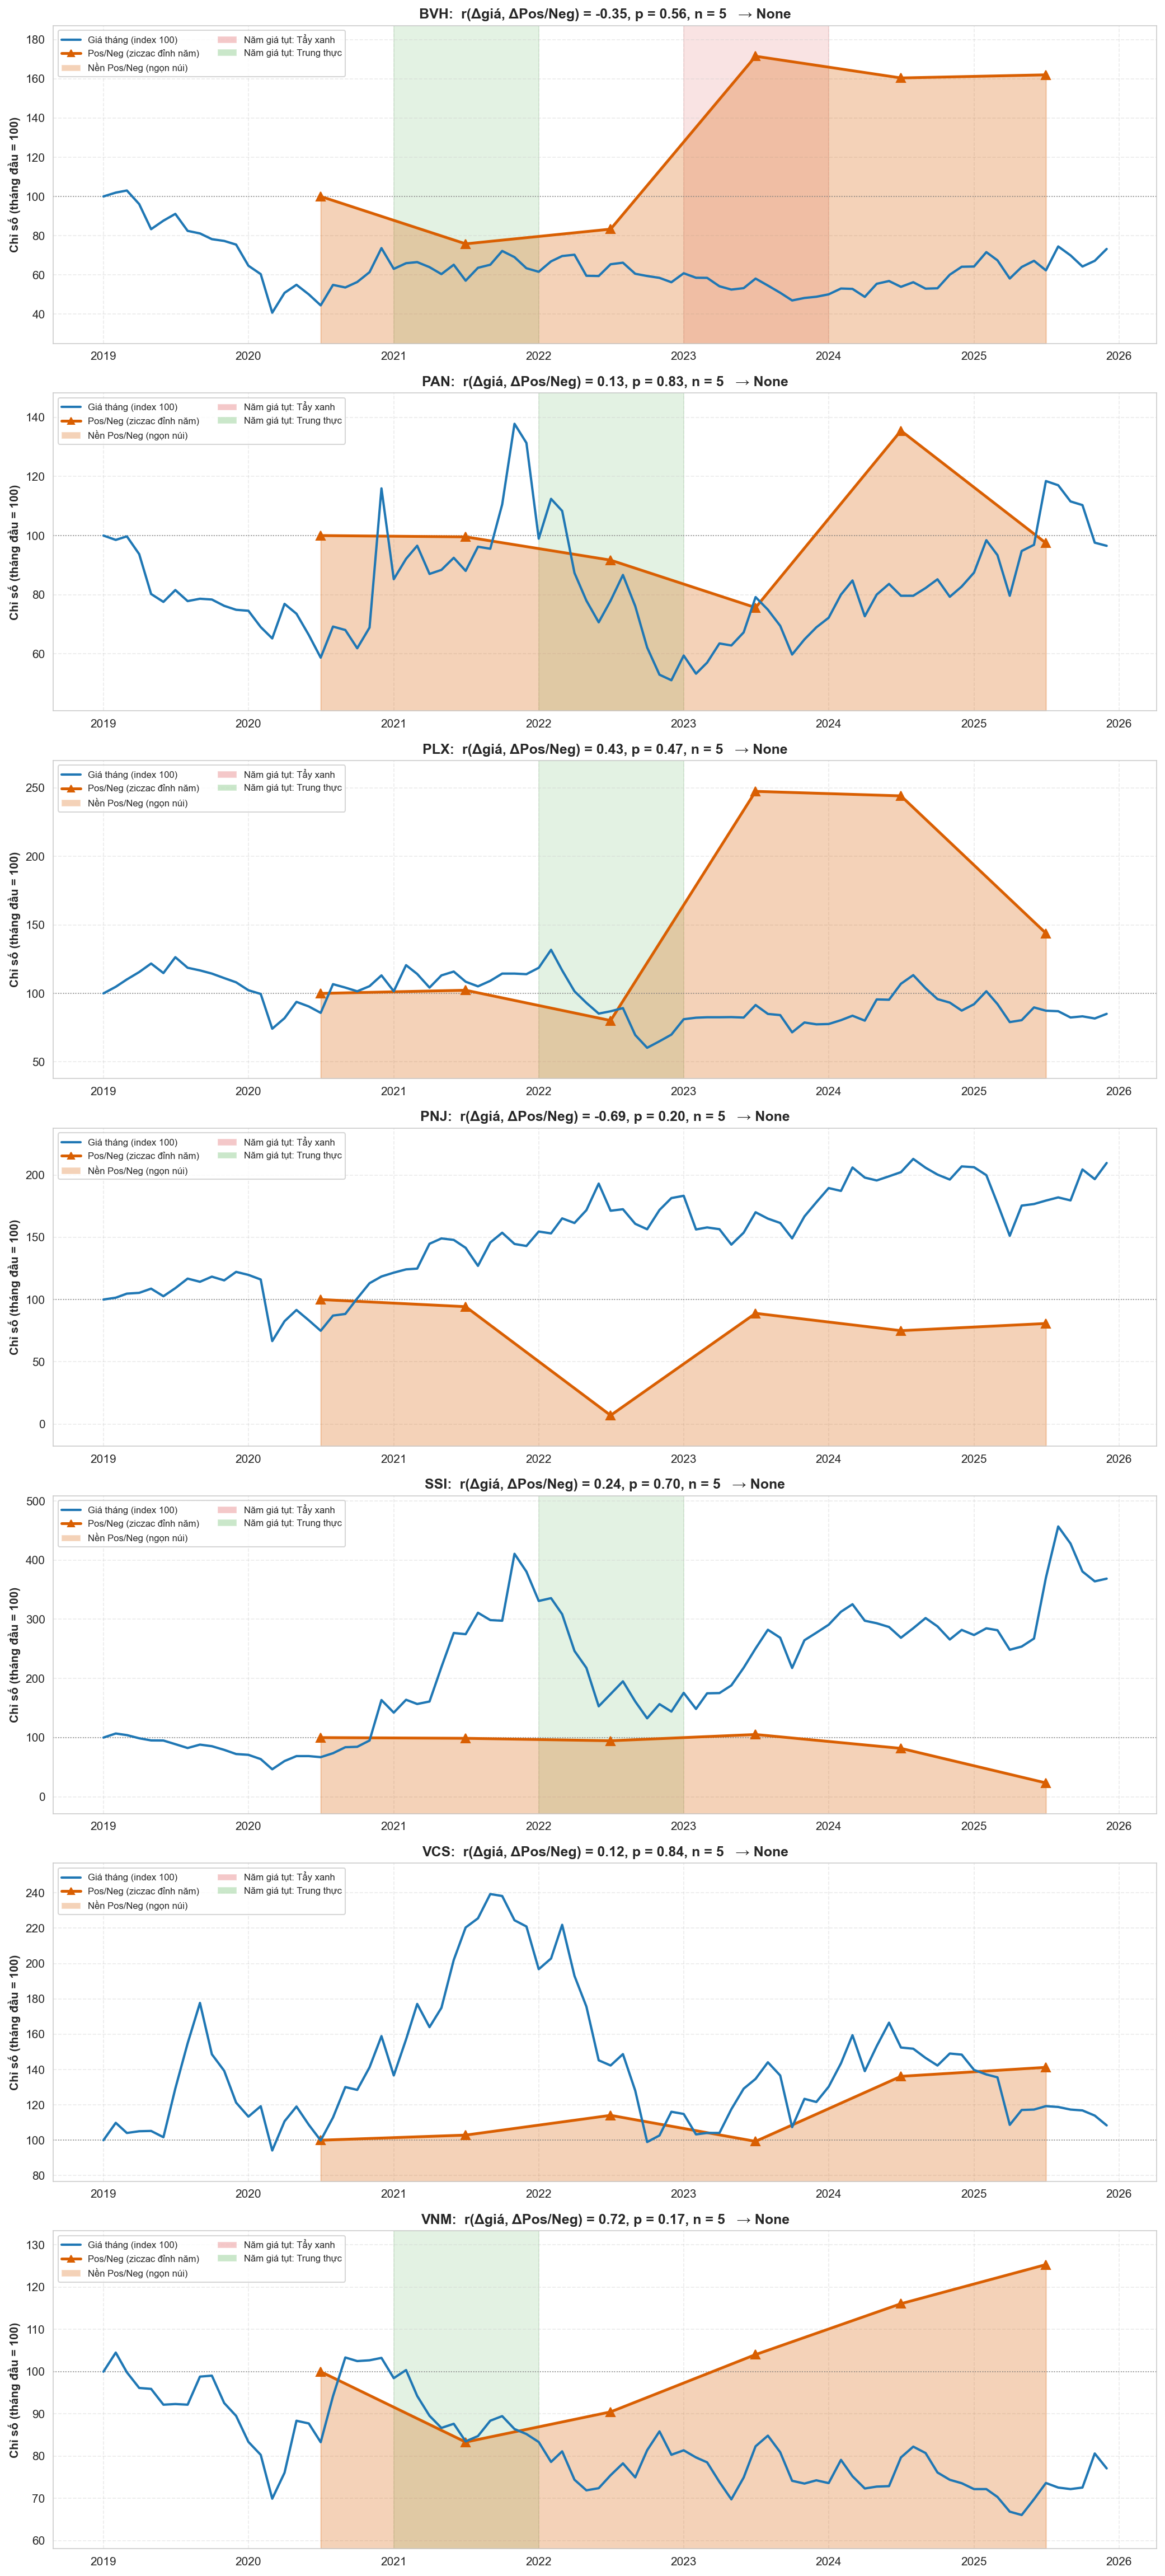

In [13]:
import importlib
import src.stock
import src.plots

importlib.reload(src.stock)
importlib.reload(src.plots)

from src.stock import build_stock_sentiment_view
from src.plots import plot_stock_vs_sentiment_greenwashing
from IPython.display import Image, display

both_path = RESULT_DIR / "result_both.pkl"
if not both_path.exists():
    print("Chưa có sentiment. Chạy: python run_pipeline.py --lang vi --sentiment-only")
else:
    df_both = pd.read_pickle(both_path)
    counts = sentiment_ratio(df_both.dropna(subset=["label"]))
    cache = RESULT_DIR / "stock_prices_monthly.csv"
    monthly, annual, corr = build_stock_sentiment_view(counts, use_live=not cache.exists())

    # --- Bảng tăng/giảm giá cổ phiếu + sentiment ratio (theo năm) ---
    tbl = annual.copy()
    want = [
        "company",
        "year",
        "close_yearend",
        "price_change_pct",
        "Positive",
        "Negative",
        "Ratio",
        "sentiment_ratio_change_pct",
        "phan_ung",
    ]
    tbl = tbl[[c for c in want if c in tbl.columns]].rename(
        columns={
            "close_yearend": "gia_cuoi_nam",
            "price_change_pct": "gia_tang_giam_%",
            "Ratio": "sent_ratio",
            "sentiment_ratio_change_pct": "sent_ratio_tang_giam_%",
        }
    )
    print("Bảng tăng/giảm giá cổ phiếu và sentiment ratio (Pos/Neg) theo năm")
    display(tbl.round(2))

    print("Giá tăng/giảm YoY (%)")
    display(annual.pivot(index="company", columns="year", values="price_change_pct").round(2))

    print("Sentiment ratio Pos/Neg theo năm")
    display(annual.pivot(index="company", columns="year", values="Ratio").round(2))

    print("Correlation: r giữa % đổi giá năm và % đổi Pos/Neg")
    display(corr)

    fig_gw_path = plot_stock_vs_sentiment_greenwashing(monthly, corr)
    print("Đã lưu", fig_gw_path)
    display(Image(filename=str(fig_gw_path)))


## 12. Mức độ tẩy xanh

Cờ nhị phân ở mục 11 (giá tụt > 10% **và** Pos/Neg tăng > 15%) gần như không bắt được năm nào. Cell này đo **mức độ** bằng điểm liên tục, chỉ tính khi giá giảm:

$$
\mathrm{GW} = \frac{\max(0, -\Delta \text{giá}\%) \times \max(0, \Delta \text{Pos/Neg}\%)}{100}
$$

- Giá tụt càng mạnh **và** giọng văn càng hồng hơn → GW càng cao.
- Giá tụt nhưng Pos/Neg cũng giảm → GW = 0 (**trung thực**).
- Giá không tụt → GW = 0 (không kết luận tẩy xanh).

| GW | Mức |
|---|---|
| 0 | Không |
| 0 – 2 | Nhẹ |
| 2 – 8 | Trung bình |
| > 8 | Mạnh |

Năm có **< 80 câu** (PLX 2021, PLX 2024) ratio nhảy mạnh — điểm chỉ để tham khảo. Đây là phân kỳ *giá vs giọng văn báo cáo*, không phải bằng chứng pháp lý.


Điểm tẩy xanh từng công ty–năm (GW > 0 chỉ khi giá giảm và Pos/Neg tăng)


,company,year,n_cau,gia_tang_giam_%,Ratio,sent_ratio_tang_giam_%,gw_score,muc_do,mau_mong
0,BVH,2019,0.0,NaN,NaN,NaN,NaN,Không,True
1,BVH,2020,5627.0,-2.39,3.62,NaN,NaN,Không,False
2,BVH,2021,6388.0,-13.95,2.75,-24.18,0.00,Trung thực,False
3,BVH,2022,6419.0,-11.28,3.02,9.90,1.12,Nhẹ,False
4,BVH,2023,3691.0,-13.18,6.22,105.89,13.96,Mạnh,False
5,BVH,2024,4037.0,31.36,5.81,-6.46,0.00,Không,False
6,BVH,2025,4515.0,14.18,5.87,0.99,0.00,Không,False
7,PAN,2019,0.0,NaN,NaN,NaN,NaN,Không,True
8,PAN,2020,1464.0,54.91,4.57,NaN,NaN,Không,False
9,PAN,2021,1572.0,13.27,4.55,-0.44,0.00,Không,False


Xếp hạng mức độ tẩy xanh (trung bình các năm)


,company,n_nam,n_nam_gia_tut,n_nam_GW>0,GW_trung_binh,GW_max,nam_GW_max,n_nam_trung_thuc
3,PNJ,6,2,1,4.35,21.75,2023,0
0,BVH,6,4,2,3.02,13.96,2023,1
5,VCS,6,2,2,1.23,5.16,2022,0
6,VNM,6,4,3,0.35,1.13,2023,1
1,PAN,6,1,0,0.00,0.00,-,1
2,PLX,6,2,0,0.00,0.00,-,1
4,SSI,6,1,0,0.00,0.00,-,1


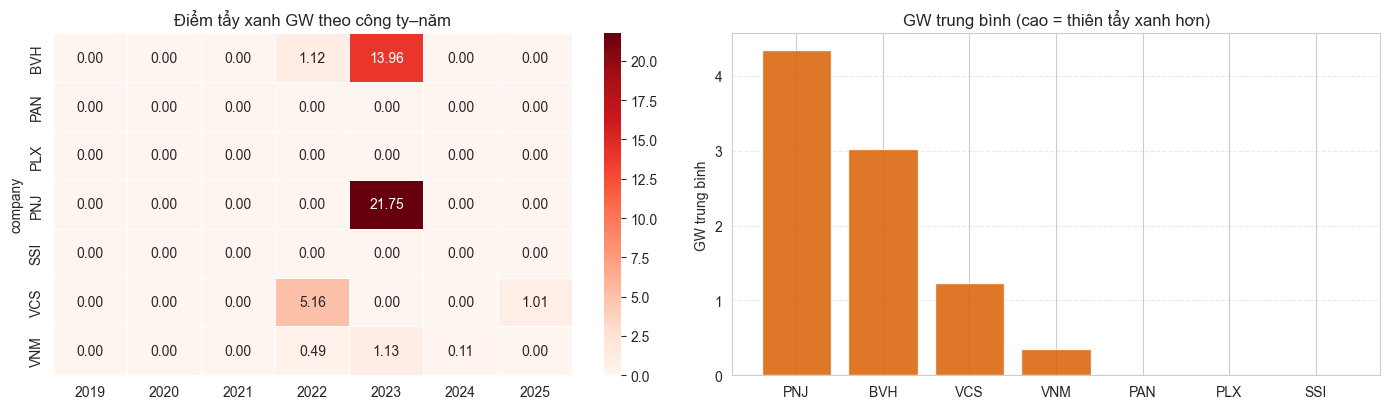

Đã lưu C:\Code\paper_sdg\figures\greenwashing_score.png


### Nhận xét
- Mẫu: **7 công ty**, **42 năm** có đủ Δ giá. GW chỉ khác 0 khi *giá giảm* và *Pos/Neg tăng* — cùng chiều thì không tính tẩy xanh.
- Năm mẫu câu mỏng (< 80), ratio dễ nhảy: **BVH 2019 (0 câu), PAN 2019 (0 câu), PLX 2019 (0 câu), PNJ 2019 (0 câu), PNJ 2022 (12 câu), SSI 2019 (0 câu), VCS 2019 (0 câu), VNM 2019 (0 câu)**. Không dùng để kết luận.
- Thiên tẩy xanh nhất trên trung bình: **PNJ** (GW TB = 4.35, max 21.75 năm 2023, 1 năm GW>0 / 2 năm giá tụt).
- Năm GW cao nhất:
  - **PNJ 2023**: GW = 21.75 (Mạnh) — giá -1.9%, Pos/Neg +1169.1%
  - **BVH 2023**: GW = 13.96 (Mạnh) — giá -13.2%, Pos/Neg +105.9%
  - **VCS 2022**: GW = 5.16 (Trung bình) — giá -47.5%, Pos/Neg +10.9%
  - **VNM 2023**: GW = 1.13 (Nhẹ) — giá -7.5%, Pos/Neg +15.0%
  - **BVH 2022**: GW = 1.12 (Nhẹ) — giá -11.3%, Pos/Neg +9.9%
- **Trung thực** (giá tụt > 10% và Pos/Neg cũng giảm): BVH 2021, PAN 2022, PLX 2022, SSI 2022, VNM 2021. Giọng văn không bị tô hồng khi thị trường phạt.
- GW trung bình = 0 (không năm nào giá tụt + giọng hồng): PAN, PLX, SSI.
- **Giới hạn:** n ≈ 6 năm/công ty, không đủ để suy thống kê (correlation cell 11 đã p > 0.10). PNJ 2022 Pos/Neg sụt mạnh dù giá tăng — ngược tẩy xanh; có thể do chất lượng extract/OCR, không phải tín hiệu ESG.

In [14]:
# Tái dùng `annual` từ cell 11 nếu đã chạy; không thì dựng lại.
from IPython.display import display, Markdown
from pathlib import Path

try:
    annual  # noqa: F821 — từ cell 11
    assert isinstance(annual, pd.DataFrame)
except (NameError, AssertionError):
    both_path = RESULT_DIR / "result_both.pkl"
    if not both_path.exists():
        raise SystemExit("Chưa có sentiment. Chạy cell 11 trước, hoặc: python run_pipeline.py --lang vi --sentiment-only")
    counts = sentiment_ratio(pd.read_pickle(both_path).dropna(subset=["label"]))
    cache = RESULT_DIR / "stock_prices_monthly.csv"
    from src.stock import build_stock_sentiment_view
    _, annual, corr = build_stock_sentiment_view(counts, use_live=not cache.exists())

gw = annual.copy()
gw["n_cau"] = gw[["Positive", "Negative", "Neutral"]].sum(axis=1) if set(
    ["Positive", "Negative", "Neutral"]
).issubset(gw.columns) else np.nan
d_p = pd.to_numeric(gw["price_change_pct"], errors="coerce")
d_r = pd.to_numeric(gw["sentiment_ratio_change_pct"], errors="coerce")
gw["gw_score"] = (np.maximum(0, -d_p) * np.maximum(0, d_r) / 100.0).round(2)
gw["mau_mong"] = gw["n_cau"] < 80


def _muc(x: float) -> str:
    if pd.isna(x) or x <= 0:
        return "Không"
    if x <= 2:
        return "Nhẹ"
    if x <= 8:
        return "Trung bình"
    return "Mạnh"


gw["muc_do"] = gw["gw_score"].map(_muc)
# Năm giá tụt + giọng văn kém đi = trung thực (đã có phan_ung); ghi rõ trên bảng mức độ
gw.loc[(d_p < -10) & (d_r < 0), "muc_do"] = "Trung thực"

show = gw[
    [
        "company",
        "year",
        "n_cau",
        "price_change_pct",
        "Ratio",
        "sentiment_ratio_change_pct",
        "gw_score",
        "muc_do",
        "mau_mong",
    ]
].rename(
    columns={
        "price_change_pct": "gia_tang_giam_%",
        "sentiment_ratio_change_pct": "sent_ratio_tang_giam_%",
    }
)
print("Điểm tẩy xanh từng công ty–năm (GW > 0 chỉ khi giá giảm và Pos/Neg tăng)")
display(show.round(2))

# Xếp hạng công ty
rows = []
for comp, g in gw.groupby("company"):
    g2 = g.dropna(subset=["price_change_pct"])
    rows.append(
        {
            "company": comp,
            "n_nam": int(len(g2)),
            "n_nam_gia_tut": int((g2["price_change_pct"] < 0).sum()),
            "n_nam_GW>0": int((g2["gw_score"] > 0).sum()),
            "GW_trung_binh": round(float(g2["gw_score"].mean()), 2),
            "GW_max": round(float(g2["gw_score"].max()), 2),
            "nam_GW_max": (str(g2.loc[g2["gw_score"].idxmax(), "year"]) if float(g2["gw_score"].max()) > 0 else "-"),
            "n_nam_trung_thuc": int((g2["muc_do"] == "Trung thực").sum()),
        }
    )
rank = pd.DataFrame(rows).sort_values(["GW_trung_binh", "GW_max"], ascending=False)
print("Xếp hạng mức độ tẩy xanh (trung bình các năm)")
display(rank)

heat = gw.pivot(index="company", columns="year", values="gw_score").fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="Reds", ax=axes[0], linewidths=0.4)
axes[0].set_title("Điểm tẩy xanh GW theo công ty–năm")
axes[0].set_xlabel("")
axes[1].bar(rank["company"], rank["GW_trung_binh"], color="#d95f02", alpha=0.85)
axes[1].set_title("GW trung bình (cao = thiên tẩy xanh hơn)")
axes[1].set_ylabel("GW trung bình")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
fig_path = FIGURE_DIR / "greenwashing_score.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu", fig_path)

gw.to_csv(RESULT_DIR / "table_greenwashing_score.csv", index=False, encoding="utf-8-sig")
rank.to_csv(RESULT_DIR / "table_greenwashing_rank.csv", index=False, encoding="utf-8-sig")

# --- Nhận xét tự sinh từ số liệu ---
thin = gw.loc[gw["mau_mong"], ["company", "year", "n_cau"]]
top = gw.sort_values("gw_score", ascending=False).head(5)
honest = gw[gw["muc_do"] == "Trung thực"]
lines = ["### Nhận xét"]
lines.append(
    f"- Mẫu: **{gw['company'].nunique()} công ty**, **{int(gw['price_change_pct'].notna().sum())} năm** có đủ Δ giá. "
    "GW chỉ khác 0 khi *giá giảm* và *Pos/Neg tăng* — cùng chiều thì không tính tẩy xanh."
)
if len(thin):
    pairs = ", ".join(f"{r.company} {r.year} ({int(r.n_cau)} câu)" for r in thin.itertuples())
    lines.append(f"- Năm mẫu câu mỏng (< 80), ratio dễ nhảy: **{pairs}**. Không dùng để kết luận.")
if rank["GW_trung_binh"].max() == 0:
    lines.append("- Không năm nào vừa giá tụt vừa giọng văn hồng hơn → **không thấy tẩy xanh** trên chỉ số này.")
else:
    lead = rank.iloc[0]
    lines.append(
        f"- Thiên tẩy xanh nhất trên trung bình: **{lead.company}** "
        f"(GW TB = {lead.GW_trung_binh:.2f}, max {lead.GW_max:.2f} năm {lead.nam_GW_max}, "
        f"{int(lead['n_nam_GW>0'])} năm GW>0 / {int(lead.n_nam_gia_tut)} năm giá tụt)."
    )
    lines.append("- Năm GW cao nhất:")
    for r in top.itertuples():
        if r.gw_score <= 0:
            break
        note = " *(mẫu mỏng)*" if r.mau_mong else ""
        lines.append(
            f"  - **{r.company} {r.year}**: GW = {r.gw_score:.2f} ({r.muc_do}) — "
            f"giá {r.price_change_pct:+.1f}%, Pos/Neg {r.sentiment_ratio_change_pct:+.1f}%{note}"
        )
if len(honest):
    pairs = ", ".join(f"{r.company} {r.year}" for r in honest.itertuples())
    lines.append(
        f"- **Trung thực** (giá tụt > 10% và Pos/Neg cũng giảm): {pairs}. "
        "Giọng văn không bị tô hồng khi thị trường phạt."
    )
low = rank[rank["GW_trung_binh"] == 0]
if len(low):
    lines.append(
        f"- GW trung bình = 0 (không năm nào giá tụt + giọng hồng): "
        + ", ".join(low["company"].tolist())
        + "."
    )
lines.append(
    "- **Giới hạn:** n ≈ 6 năm/công ty, không đủ để suy thống kê (correlation cell 11 đã p > 0.10). "
    "PNJ 2022 Pos/Neg sụt mạnh dù giá tăng — ngược tẩy xanh; có thể do chất lượng extract/OCR, không phải tín hiệu ESG."
)
display(Markdown("\n".join(lines)))


---
Khi PDF mới về: `python process_data.py` rồi `python run_pipeline.py --lang vi` (hoặc `en`), sau đó **Run All** notebook này — vẫn không cần load model.